In [1]:
# !For this plot a functioning LaTeX installation must be on the computer

import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
import pandas as pd
import seaborn as sns
import os
import re
from pyfish import fish_plot, process_data, setup_figure

In [2]:
if not os.path.isdir('figures'):
    os.mkdir('figures')

# Confinement comparisons

In [3]:
def ratio(pop_total, pop_alive, conf):
    if pop_total == 0:
        return 0
    elif conf == 0:
        return 1
    else:
        return min(shell(pop_total, conf) / pop_alive, 1)
    
def shell(pop_total, conf):
    return pop_total - 4/3*np.pi * (core(pop_total, conf))**3
                                                   
def core(pop_total, conf):
    return max((3/4*(pop_total)/np.pi)**(1/3) - 1/conf, 0)

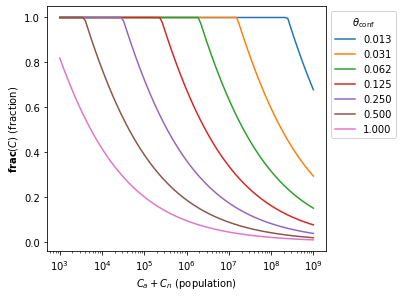

In [4]:
plt.figure(figsize=(5, 4.5))

# log scaled array from 0.01 to 1.0 with 16 steps
conf = [0.0125, 0.03125, 0.0625, 0.125, 0.25, 0.5, 1]

# log scaled array from 1000 to 10^9 with 100 steps
pop = np.logspace(3, 9, 100)


# Plot
plt.xscale('log')
plt.xlabel(r'$C_a + C_n$ (population)')
plt.ylabel(r'${\bf {frac}}(C)$ (fraction)')
for con in conf:
    plt.plot(pop, np.array([ratio(p, p / 2, con) for p in pop]))

# create an artist for the legend
legend_elements = ['{:.3f}'.format(c) for c in conf]

# plot legend from the artist outside of the plot with anchor top right and text "confinement"
plt.legend(legend_elements, loc='upper left', title=r'$\theta_{\rm{conf}}$',  bbox_to_anchor=(1, 1))

# save the plot as a PDF
plt.savefig('figures/confinement.pdf', bbox_inches = 'tight')

# save the plot as a Png
plt.savefig('figures/confinement.png', bbox_inches = 'tight')

# Comparison of fitness accumulation functions

In [5]:
def sum_fit(iterations, value):
    res = [1]
    for i in range(iterations - 1):
        res.append(res[-1] + value)
    return res     

def mul_fit(iterations, value):
    res = [1]
    for i in range(iterations - 1):
        res.append(res[-1] * (1 + value))
    return res     

def eth_fit(iterations, value):
    MAX_FIT = 10
    res = [1]
    for i in range(iterations - 1):
        res.append(res[-1] * (1 + value * (1 - res[-1] / MAX_FIT)))
    return res

def log_mul_fit(iterations, value):
    return [1 + np.log(x) for x in mul_fit(iterations, value)]

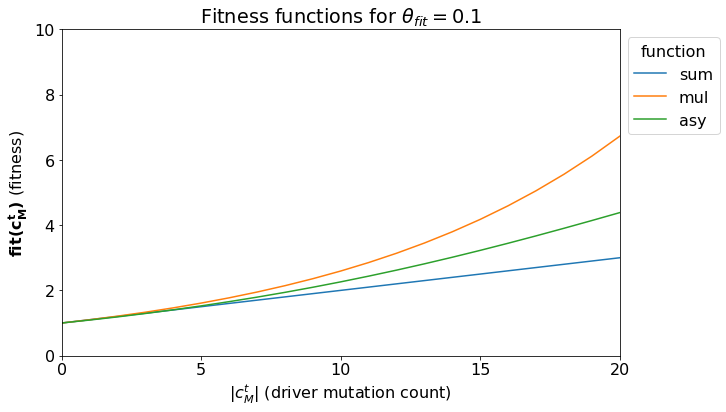

In [6]:
# set plot size to (16, 9)
plt.rcParams['figure.figsize'] = [10, 6]
# set font size to 16
plt.rcParams['font.size'] = 16

steps = list(range(0, 21))

fit = 0.1
plt.plot(steps, sum_fit(21, fit))
plt.plot(steps, mul_fit(21, fit))
plt.plot(steps, eth_fit(21, fit))

plt.ylabel(r'${\bf fit(c^t_M)}$ (fitness)')
plt.xlabel(r'$|c^t_M|$ (driver mutation count)')
plt.xlim(0, 20)
plt.ylim(0, 10)
plt.legend(['sum', 'mul', 'asy'], loc='upper left', title='function',  bbox_to_anchor=(1, 1))

# title 
plt.title(r'Fitness functions for $\theta_{fit}=0.1$')
# set x ticks to [0,5,10,15,20]
plt.xticks([0,5,10,15,20])

# save the plot as a PNG and PDF   
plt.savefig('figures/fitness_functions.png', bbox_inches = 'tight')
plt.savefig('figures/fitness_functions.pdf', bbox_inches = 'tight')



# Homeostatic population

In [7]:
populations_df = pd.read_csv("./data/passengers/populations.csv")
parent_tree_df = pd.read_csv("./data/passengers/parent_tree.csv")

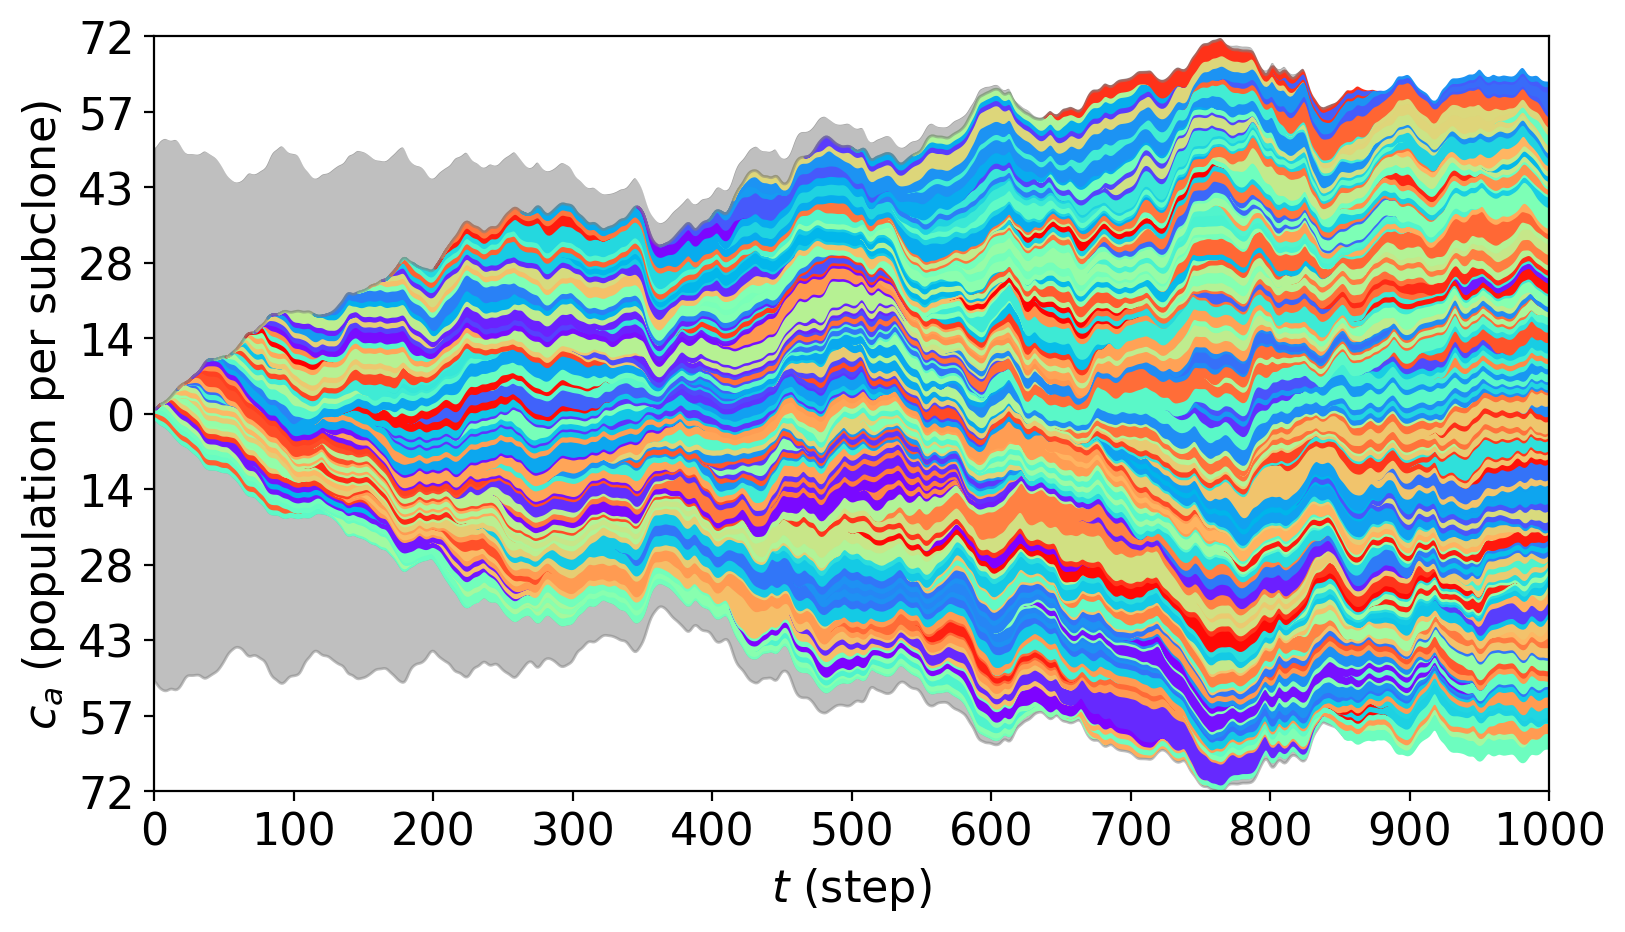

<Figure size 720x432 with 0 Axes>

In [8]:
data = process_data(populations_df, parent_tree_df, smooth=2, absolute=True)
width = 1920
height = 1080
dpi = 200
plt.figure(figsize=(width // dpi, height // dpi), dpi=dpi)
plt.xlabel(r'$t$ (step)')
plt.ylabel(r'$c_a$ (population per subclone)')
fish_plot(*data)
plt.show()

# save the plot as a PDF
plt.savefig('figures/passengers.pdf', bbox_inches='tight')

# save the plot as a Png
plt.savefig('figures/passengers.png', bbox_inches='tight')


# Performance Comparison

In [9]:
SMITH_conf_path = "./data/performance_SMITH_conf/"
tumopp_path = "./data/performance_tumopp/"
SMITH_no_path = "./data/performance_SMITH_no_conf/"

In [10]:
smith_list = []
SMITH_conf_files = os.listdir(SMITH_conf_path)
for file in SMITH_conf_files:
    # read file by lines
    with open(SMITH_conf_path + file, "r") as f:
        lines = f.readlines()
        for line in lines:
            # find if line matches the pattern "Total time: .*"
            if re.match("Total time: (.*)", line):
                time_str = re.match("Total time: (.*)", line).group(1)
                # parse time string from "hh:mm:ss.lll" to seconds
                parts = time_str.split(".")
                time = (sum(x * int(t) for x, t in zip([3600, 60, 1], parts[0].split(":"))) + float("0." + parts[1])) / 10
                file_count = file.split(".")[0]
                smith_list.append((file_count, time))              
smith_conf_data = pd.DataFrame(smith_list, columns=["size", "time"])
smith_conf_data["size"] = smith_conf_data["size"].astype('int')
smith_conf_data["time"] = smith_conf_data["time"].astype('float')
smith_conf_data



,size,time
0,10000,0.0714
1,100000,0.0742
2,1000000,0.2805
3,10000000,1.3227
4,100000000,9.6428
5,1000000000,265.4714


In [11]:
smith_list = []
SMITH_no_files = os.listdir(SMITH_no_path)
for file in SMITH_no_files:
    # read file by lines
    with open(SMITH_no_path + file, "r") as f:
        lines = f.readlines()
        for line in lines:
            # find if line matches the pattern "Total time: .*"
            if re.match("Total time: (.*)", line):
                time_str = re.match("Total time: (.*)", line).group(1)
                # parse time string from "hh:mm:ss.lll" to seconds
                parts = time_str.split(".")
                time = (sum(x * int(t) for x, t in zip([3600, 60, 1], parts[0].split(":"))) + float("0." + parts[1])) / 10
                file_count = file.split(".")[0]
                smith_list.append((file_count, time))                
smith_no_data = pd.DataFrame(smith_list, columns=["size", "time"])
smith_no_data["size"] = smith_no_data["size"].astype('int')
smith_no_data["time"] = smith_no_data["time"].astype('float')
smith_no_data




,size,time
0,10000,0.0476
1,100000,0.0395
2,1000000,0.0642
3,10000000,0.1446
4,100000000,0.2131
5,1000000000,8.9508


In [17]:
tumopp_list = []
tumopp_files = [file for file in os.listdir(tumopp_path) if file.endswith(".out")]
for file in tumopp_files:
    # read file by lines
    with open(tumopp_path + file, "r") as f:
        lines = f.readlines()
        sum = 0
        for line in lines:
            # find if line matches the pattern "Total time: .*"
            if re.match("(\d*,\d*)", line):
                time_str = re.match("(\d*,\d*)", line).group(1).replace(",", ".")     
                sum += float(time_str)
        file_count = file.split(".")[0]      
        tumopp_list.append((file_count, sum / 10))
tumopp_data = pd.DataFrame(tumopp_list, columns=["size", "time"])
tumopp_data.head(20)

# set tumpop data columns to int, float
tumopp_data["size"] = tumopp_data["size"].astype('int')
tumopp_data["time"] = tumopp_data["time"].astype('float')
tumopp_data

,size,time
0,10000,0.4727
1,100000,8.2664
2,1000000,57.1776
3,10000000,2341.5443


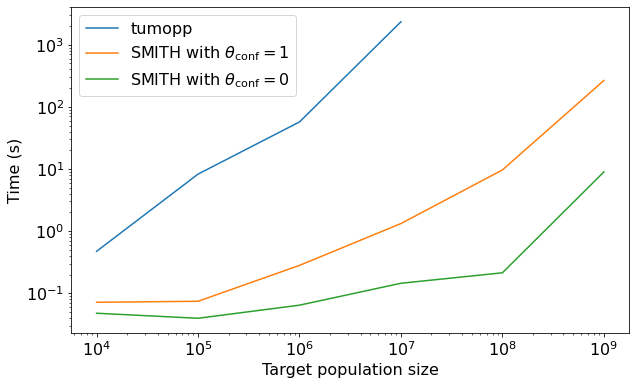

In [20]:
plt.plot(tumopp_data["size"], tumopp_data["time"], label="tumopp")
plt.plot(smith_conf_data["size"], smith_conf_data["time"], label=r"SMITH with $\theta_{\rm{conf}} = 1$")
plt.plot(smith_no_data["size"], smith_no_data["time"], label=r"SMITH with $\theta_{\rm{conf}} = 0$")
# set y log scale
plt.yscale("log")
plt.xscale("log")
plt.xlabel("Target population size")
plt.ylabel("Time (s)")
plt.legend()

# save the plot as a PDF
plt.savefig('figures/performance.pdf', bbox_inches = 'tight')

# save the plot as a Png
plt.savefig('figures/performance.png', bbox_inches = 'tight')